<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [2]:
# loading the data: Wholesale customers data
df = pd.read_csv("../data/Wholesale customers data.csv")
display(df.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

Dataset shape:  (440, 9)
First few rows: 


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,total_spending
0,2,3,12669,9656,7561,214,2674,1338,34112
1,2,3,7057,9810,9568,1762,3293,1776,33266
2,2,3,6353,8808,7684,2405,3516,7844,36610
3,1,3,13265,1196,4221,6404,507,1788,27381
4,2,3,22615,5410,7198,3915,1777,5185,46100


Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
total_spending      int64
dtype: object

Column Descriptions:

- Fresh: Spending on fresh products
- Milk: Spending on milk products
- Grocery: Spending on grocery items
- Frozen: Spending on frozen products
- Detergents_Paper: Spending on detergents and paper products
- Delicassen: Spending on delicatessen items
- Channel: 1=Hotel/Restaurant/Cafe, 2=Retail
- Region: Customer region


Categorical columns: []
Numeric columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen', 'total_spending']

Missing values:


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
total_spending      0
dtype: int64

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,total_spending
Channel,1.000000,0.062028,-0.169172,0.460720,0.608792,-0.202046,0.636026,0.056011,0.351177
Region,0.062028,1.000000,0.055287,0.032288,0.007696,-0.021044,-0.001483,0.045212,0.039039
Fresh,-0.169172,0.055287,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690,0.575178
Milk,0.460720,0.032288,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368,0.776909
Grocery,0.608792,0.007696,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497,0.740680
Frozen,-0.202046,-0.021044,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947,0.388436
Detergents_Paper,0.636026,-0.001483,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291,0.633882
Delicassen,0.056011,0.045212,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000,0.496849
total_spending,0.351177,0.039039,0.575178,0.776909,0.740680,0.388436,0.633882,0.496849,1.000000


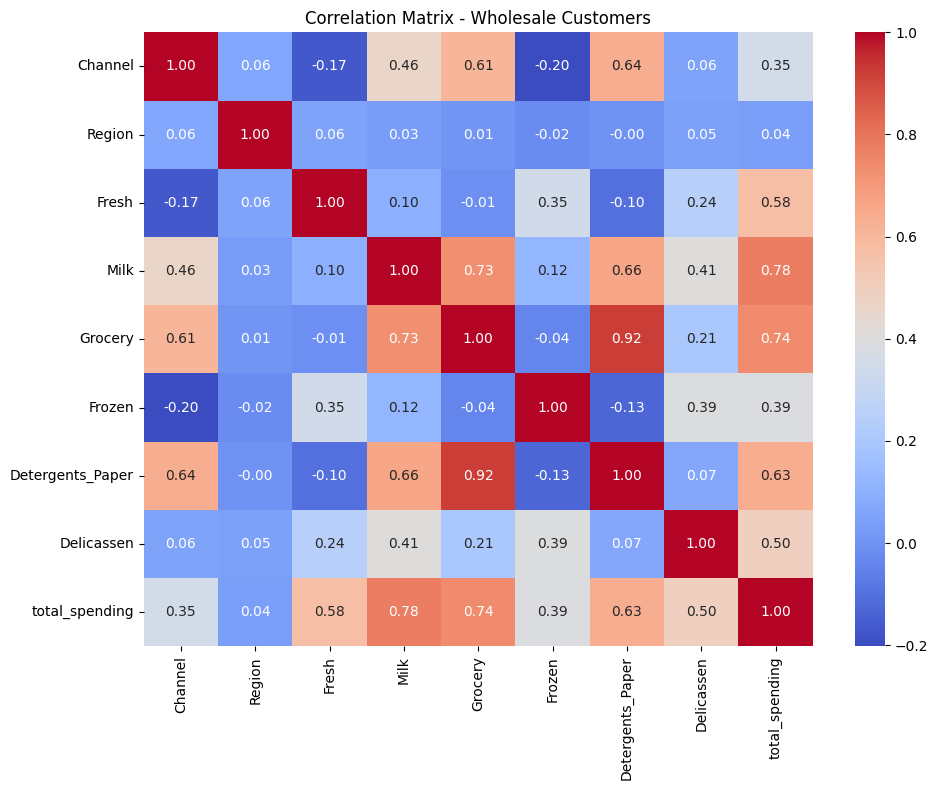

          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  total_spending  
count    440.000000        440.000000    440.000000      440.000000  
mean    3071.931818       2881.493182   1524.870455    33226.136364  
std     4854.673333       4767.854448   2820.105937    26356.301730  
min       25.000000          3.0000

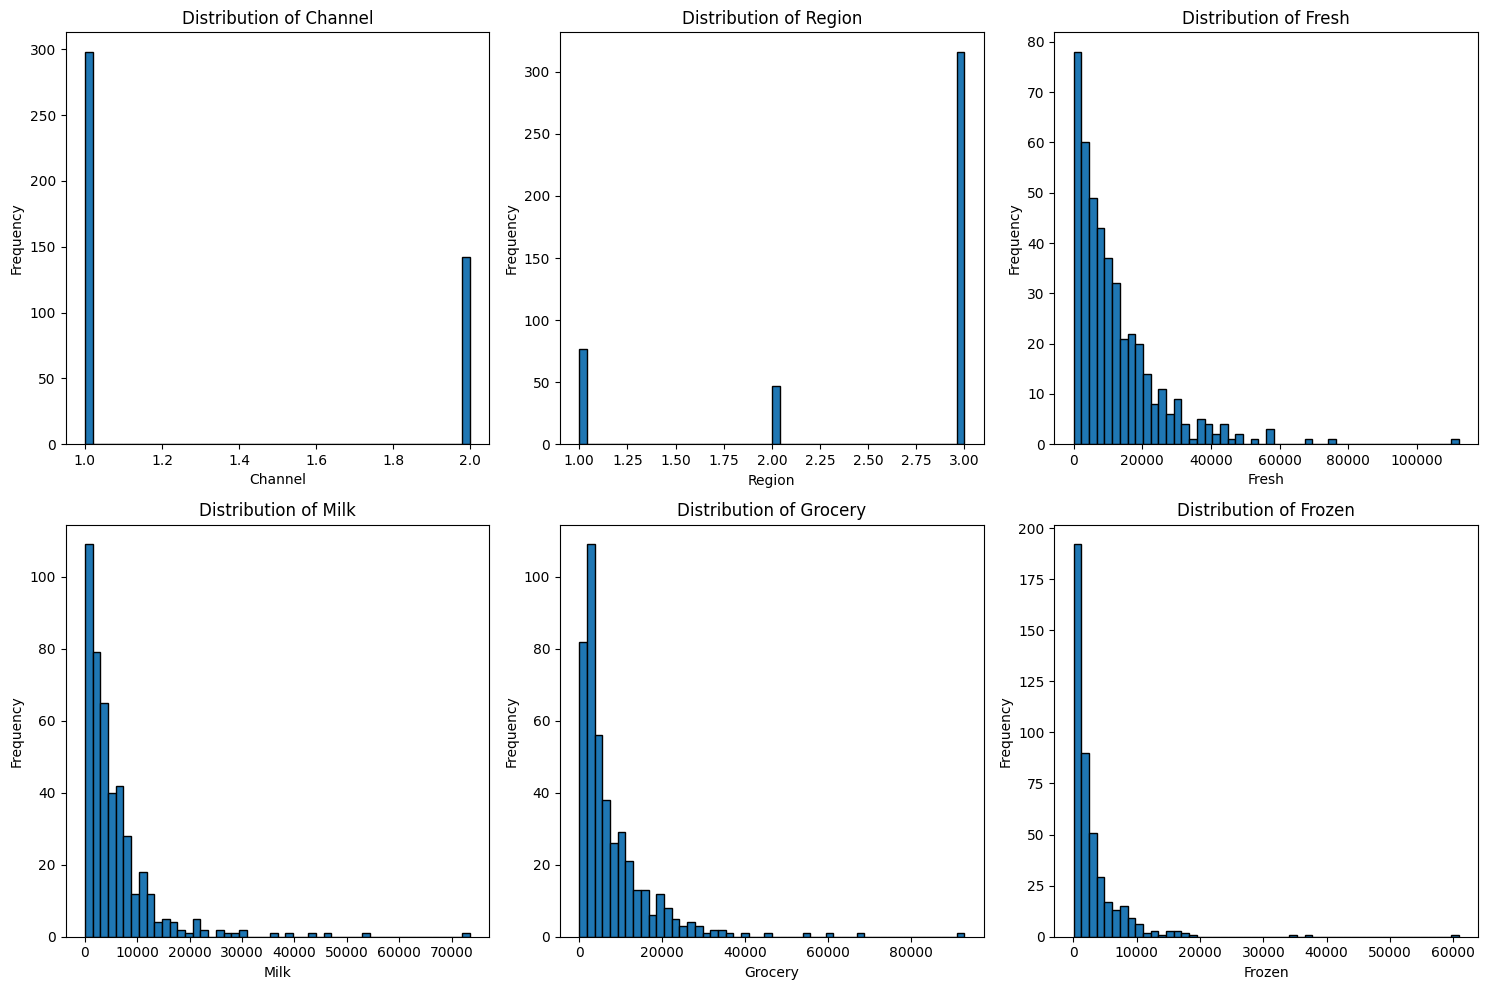


Pareto Principle Analysis:
Total customers: 440
Customers needed for 80% of sales: 80.14%
This is approximately 352 customers


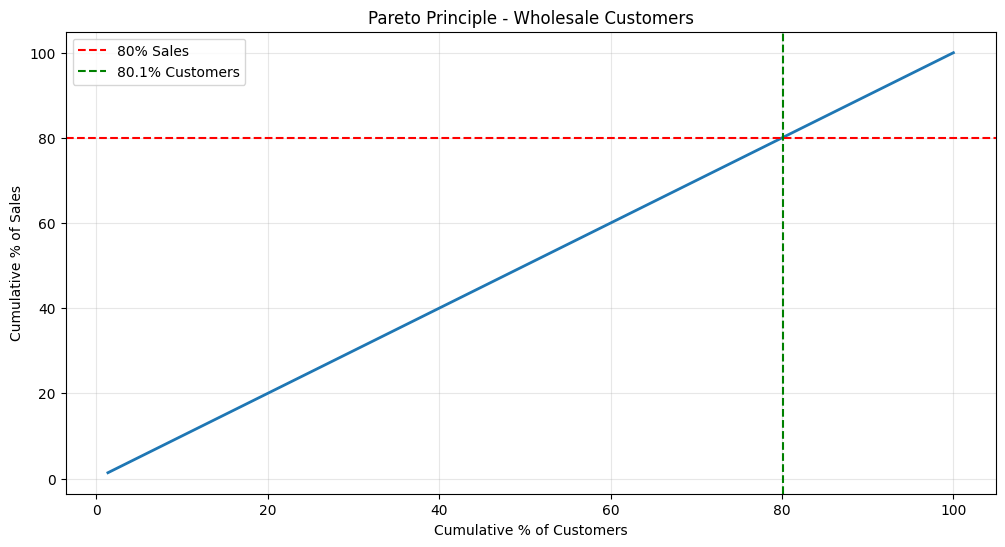

In [26]:
# Check the shape of the dataset
print("Dataset shape: ", df.shape)
print("First few rows: ")
display(df.head())

# Print column names and types
print(df.dtypes)

print("\nColumn Descriptions:")
print("""
- Fresh: Spending on fresh products
- Milk: Spending on milk products
- Grocery: Spending on grocery items
- Frozen: Spending on frozen products
- Detergents_Paper: Spending on detergents and paper products
- Delicassen: Spending on delicatessen items
- Channel: 1=Hotel/Restaurant/Cafe, 2=Retail
- Region: Customer region
""")

# Check for categorical data
print("\nCategorical columns:", df.select_dtypes(include=['object']).columns.tolist())
print("Numeric columns:", df.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Check for missing data
print("\nMissing values:")
display(df.isna().sum())

# Check fot column correlations
correlation_matrix = df.corr()
display(correlation_matrix)

# Visualzing correlation with a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Wholesale Customers')
plt.tight_layout()
plt.show()

# Descriptive Statistics
print(df.describe())

# Check for outliers
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}: {len(outliers)} outliers found")


# Distribution analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for i, col in enumerate(numeric_cols[:6]):
    axes[i].hist(df[col], bins=50, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check fot Pareto Principle
# Calculate total spending of every customer
df['total_spending'] = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].sum(axis=1)

# Sort by total spending
sorted_customers = df.sort_values('total_spending', ascending=False).reset_index(drop=True)

# calculate cumulative percentage
sorted_customers['cumulative_sum'] = sorted_customers['total_spending'].cumsum()
total_spending = sorted_customers['total_spending'].sum()
sorted_customers['cumulative_percent'] = (sorted_customers['cumulative_sum'] / total_spending) * 100
sorted_customers['customer_percent'] = (np.arange(1, len(sorted_customers) + 1) / len(sorted_customers)) * 100

# Find what percentage of customers account for 80% of sales
pareto_point = sorted_customers[sorted_customers['cumulative_percent'] >= 80].iloc[0]
pareto_customer_pct = pareto_point['cumulative_percent']

print(f"\nPareto Principle Analysis:")
print(f"Total customers: {len(sorted_customers)}")
print(f"Customers needed for 80% of sales: {pareto_customer_pct:.2f}%")
print(f"This is approximately {int(len(sorted_customers) * pareto_customer_pct / 100)} customers")

# Visualize Pareto
plt.figure(figsize=(12, 6))
plt.plot(sorted_customers['cumulative_percent'], sorted_customers['cumulative_percent'], linewidth=2)
plt.axhline(y=80, color='r', linestyle='--', label='80% Sales')
plt.axvline(x=pareto_customer_pct, color='g', linestyle='--', label=f'{pareto_customer_pct:.1f}% Customers')
plt.xlabel('Cumulative % of Customers')
plt.ylabel('Cumulative % of Sales')
plt.title('Pareto Principle - Wholesale Customers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Your observations here**

- ex.: Frozen, Grocery, Milk and Detergents Paper have a high...
- ...



# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.


1. Removing Outliers using IQR method...
   Fresh: 20 outliers removed (bounds: -17581.25 - 37642.75)
   Milk: 28 outliers removed (bounds: -6952.88 - 15676.12)
   Grocery: 24 outliers removed (bounds: -10601.12 - 23409.88)
   Frozen: 43 outliers removed (bounds: -3475.75 - 7772.25)
   Detergents_Paper: 30 outliers removed (bounds: -5241.12 - 9419.88)
   Delicassen: 27 outliers removed (bounds: -1709.75 - 3938.25)

   Total rows with outliers: 108
   Dataset shape after removing outliers: (332, 9)

2. Converting Categorical Variables to Dummy Variables...
   Channel unique values: [2 1]
   Region unique values: [3 1 2]
   Dataset shape after converting categoricals: (332, 10)
   New columns: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen', 'total_spending', 'Channel_2', 'Region_2', 'Region_3']

3. Updated Descriptive Statistics:
              Fresh          Milk       Grocery       Frozen  \
count    332.000000    332.000000    332.000000   332.000000   
mean  

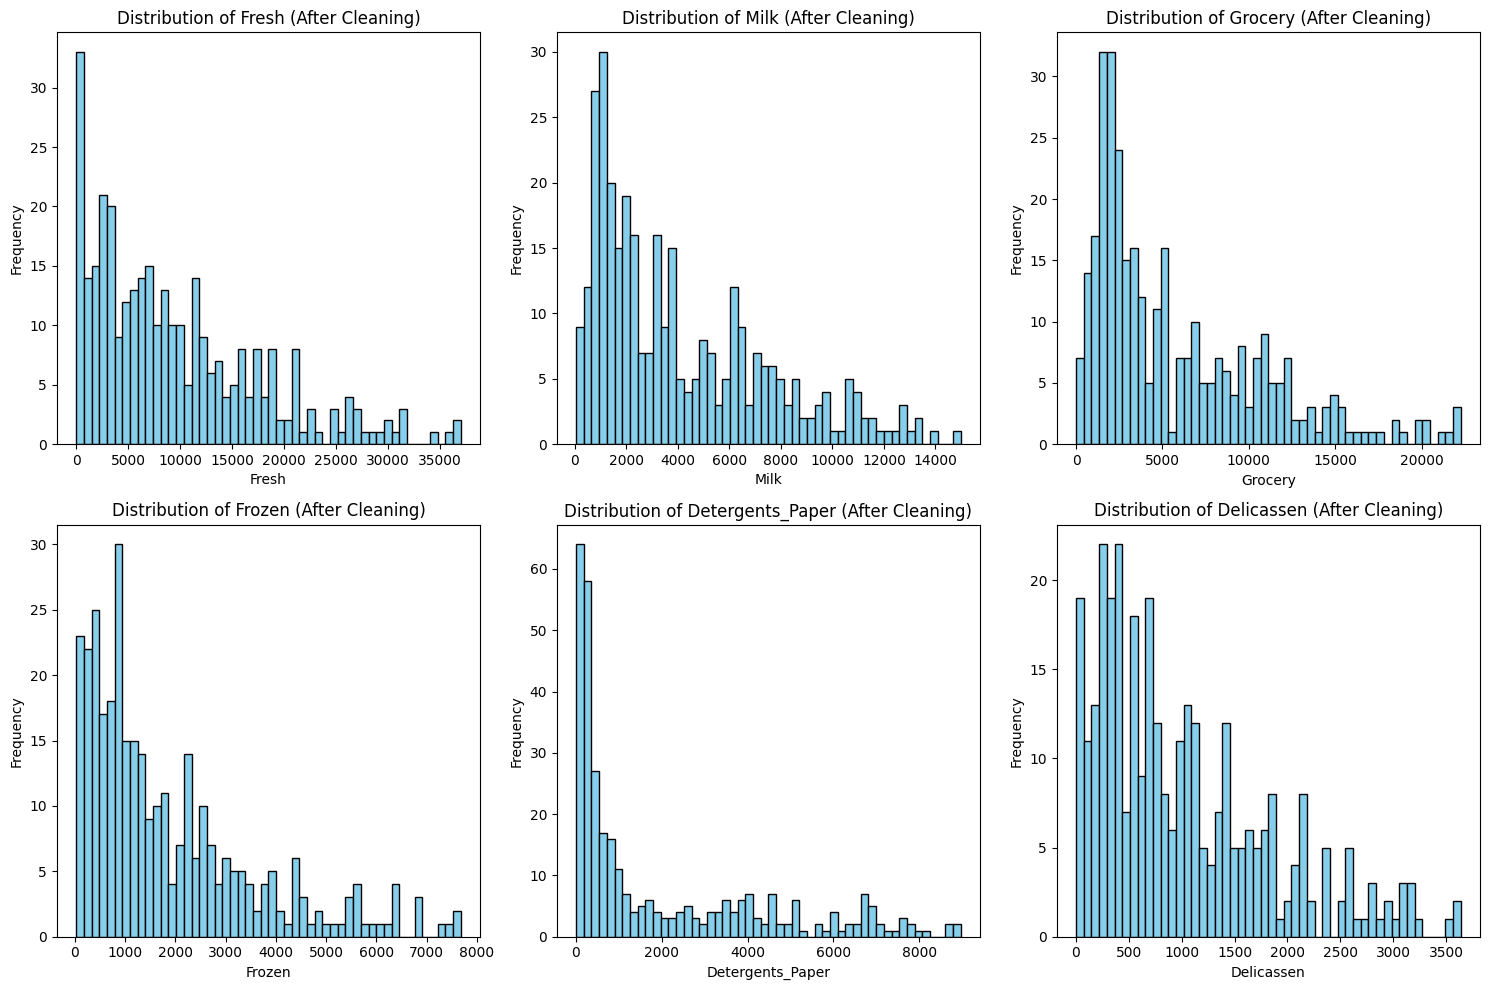


Cleaned dataset shape: (332, 10)
Data is now ready for preprocessing and clustering!


In [35]:
# 1. Remove outliers using IQR method
print("\n1. Removing Outliers using IQR method...")

# Create a copy to work with
clean_customers = df.copy()

# Define columns to check for outliers (excluding Channel and Region)
product_columns = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

outlier_indices = []

for col in product_columns:
    Q1 = clean_customers[col].quantile(0.25)
    Q3 = clean_customers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    col_outliers = clean_customers[(clean_customers[col] < lower_bound) | 
                                   (clean_customers[col] > upper_bound)].index
    outlier_indices.extend(col_outliers)
    
    print(f"   {col}: {len(col_outliers)} outliers removed (bounds: {lower_bound:.2f} - {upper_bound:.2f})")


# Remove duplicate indices
outlier_indices = list(set(outlier_indices))
print(f"\n   Total rows with outliers: {len(outlier_indices)}")

clean_customers = clean_customers.drop(outlier_indices)
print(f"   Dataset shape after removing outliers: {clean_customers.shape}")


# 2. Convert categorical columns using get_dummies
print("\n2. Converting Categorical Variables to Dummy Variables...")

# Channel: 1=Hotel/Restaurant/Cafe, 2=Retail
# Region: Regions 1-3

print(f"   Channel unique values: {clean_customers['Channel'].unique()}")
print(f"   Region unique values: {clean_customers['Region'].unique()}")

# Create dummy variables
clean_customers = pd.get_dummies(clean_customers, 
                                  columns=['Channel', 'Region'], 
                                  drop_first=True)

print(f"   Dataset shape after converting categoricals: {clean_customers.shape}")
print(f"   New columns: {clean_customers.columns.tolist()}")

# 3. Check cleaned data statistics
print("\n3. Updated Descriptive Statistics:")
print(clean_customers.describe())

# 4. Verify no missing values
print("\n4. Missing values check:")
print(clean_customers.isnull().sum())

# 5. Visualize cleaned data
print("\n5. Visualizing cleaned data distributions...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

product_columns = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

for idx, col in enumerate(product_columns):
    axes[idx].hist(clean_customers[col], bins=50, edgecolor='black', color='skyblue')
    axes[idx].set_title(f'Distribution of {col} (After Cleaning)')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nCleaned dataset shape: {clean_customers.shape}")
print("Data is now ready for preprocessing and clustering!")

**Your comment here**

-  ...
-  ...

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [41]:
# Your import here:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(clean_customers)

customers_scale = scaler.transform(clean_customers)

customers_scale = pd.DataFrame(customers_scale, columns=clean_customers.columns)

print("\nBefore Scaling (Original):")
print(clean_customers[['Fresh', 'Milk', 'Grocery', 'Frozen']].describe())

print("\nAfter Scaling:")
print(customers_scale[['Fresh', 'Milk', 'Grocery', 'Frozen']].describe())



Before Scaling (Original):
              Fresh          Milk       Grocery       Frozen
count    332.000000    332.000000    332.000000   332.000000
mean    9547.397590   4105.180723   5875.614458  1863.048193
std     8161.831206   3363.303146   5038.930756  1707.890373
min        3.000000     55.000000      3.000000    25.000000
25%     2989.750000   1352.500000   2011.500000   582.000000
50%     7483.500000   3087.000000   3835.500000  1270.500000
75%    13987.250000   6251.750000   8928.500000  2587.500000
max    37036.000000  14982.000000  22272.000000  7683.000000

After Scaling:
              Fresh          Milk       Grocery        Frozen
count  3.320000e+02  3.320000e+02  3.320000e+02  3.320000e+02
mean  -1.177104e-16  1.284113e-16  5.350472e-17 -1.605142e-17
std    1.001509e+00  1.001509e+00  1.001509e+00  1.001509e+00
min   -1.171159e+00 -1.206045e+00 -1.167208e+00 -1.077834e+00
25%   -8.046657e-01 -8.196810e-01 -7.680096e-01 -7.512086e-01
50%   -2.532536e-01 -3.031893e-01 -

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [42]:
from sklearn.cluster import KMeans

# Your code here:
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customers_scale)

### Looking to the elbow we can choose 2 like the correct number of clusters

In [43]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

In [44]:
clean_customers['Label'] = clusters

Count the values in `labels`.

In [ ]:
# Your code here:
display(clean_customers['Label'].value_counts())

np.int64(332)

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [49]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5)
dbscan.fit(customers_scale)

clean_customers['labels_DBSCAN'] = dbscan.labels_


# Your code here


Count the values in `labels_DBSCAN`.

In [ ]:
# Your code here
print(clean_customers['labels_DBSCAN'].value_counts())


332


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [77]:
import seaborn as sns

def plot(x,y,hue, ax):
    sns.scatterplot(data=clean_customers,
                    x=x, 
                    y=y,
                    hue=hue,
                    ax=ax)

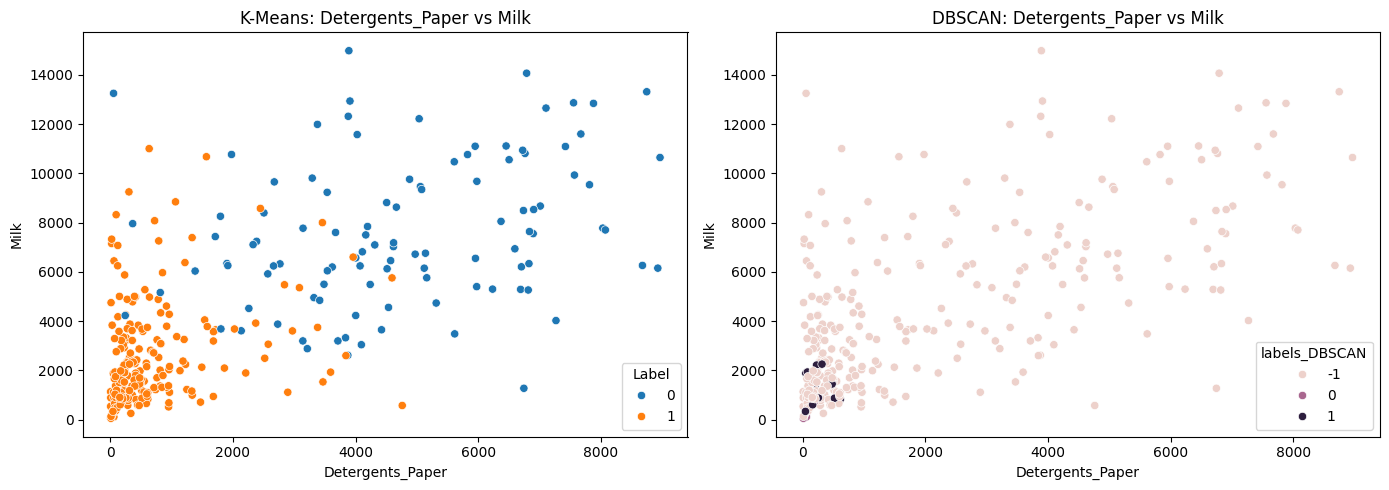

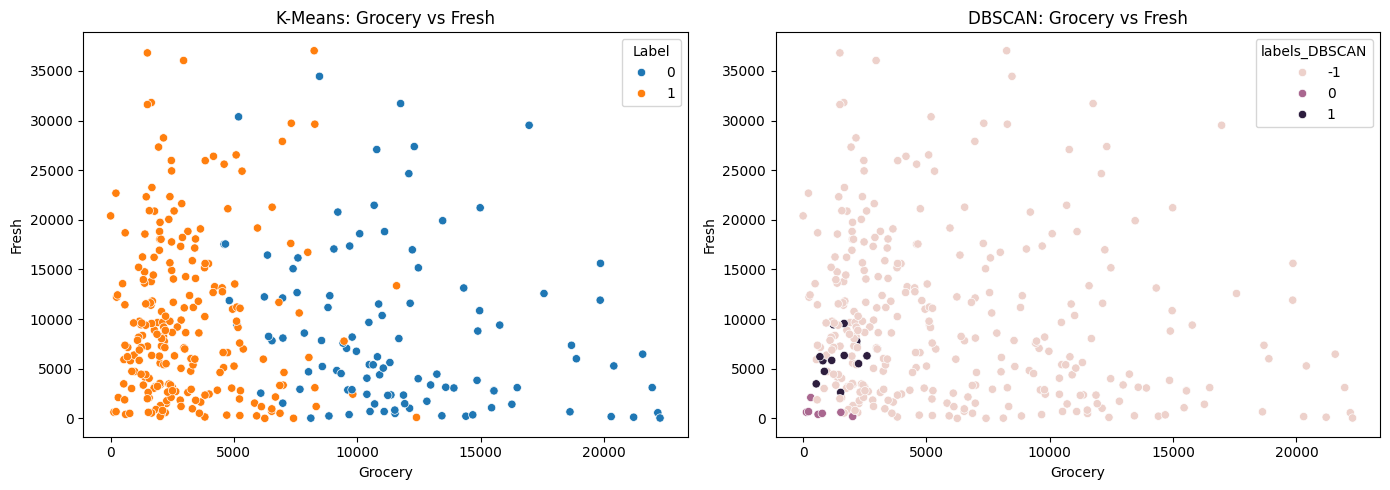

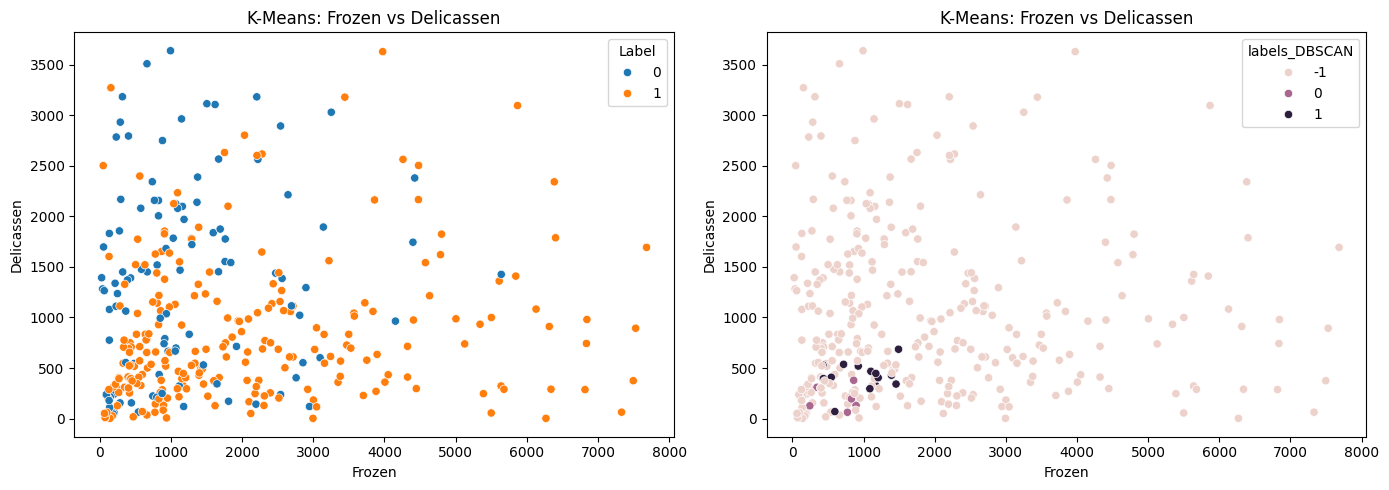

In [ ]:
# Your code here:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot('Detergents_Paper', 'Milk', 'Label', axes[0])
axes[0].set_title('K-Means: Detergents_Paper vs Milk')
plot('Detergents_Paper', 'Milk', 'labels_DBSCAN', axes[1])
axes[1].set_title('DBSCAN: Detergents_Paper vs Milk')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot('Grocery', 'Fresh', 'Label', axes[0])
axes[0].set_title('K-Means: Grocery vs Fresh')
plot('Grocery', 'Fresh', 'labels_DBSCAN', axes[1])
axes[1].set_title('DBSCAN: Grocery vs Fresh')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot('Frozen', 'Delicassen', 'Label', axes[0])
axes[0].set_title('K-Means: Frozen vs Delicassen')
plot('Frozen', 'Delicassen', 'labels_DBSCAN', axes[1])
axes[1].set_title('DBSCAN: Frozen vs Delicassen')

plt.tight_layout()
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
# Your code here:

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
# Your code here:

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [ ]:
# Your code here:

Which algorithm appears to perform better?

**Your observations here**

- 

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [41]:
# Your code here:

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [ ]:
# Your code here

**Your comment here**

- 